Searching for data files...
Found train.csv at: /kaggle/input/competitions/triagegeist/train.csv
Merging data...

--- 1. Triage Acuity (ESI) Distribution ---


/tmp/ipykernel_121/4204645306.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='triage_acuity', order=[1, 2, 3, 4, 5], palette="Reds_r", ax=ax)


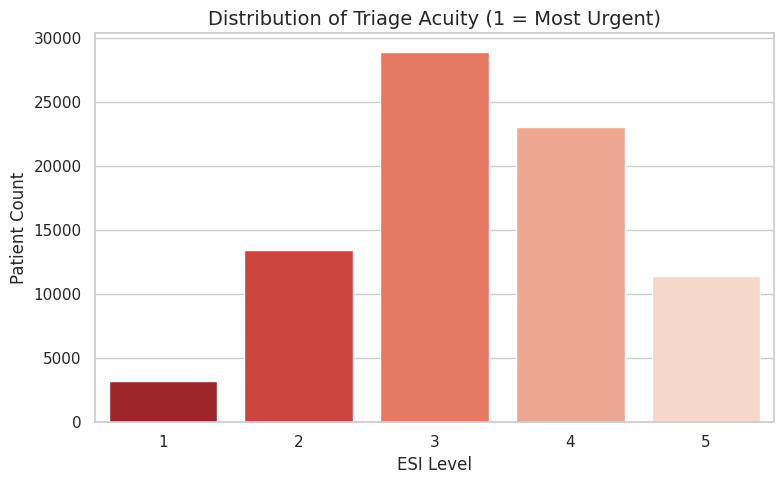


--- 2. MNAR Vitals Analysis ---


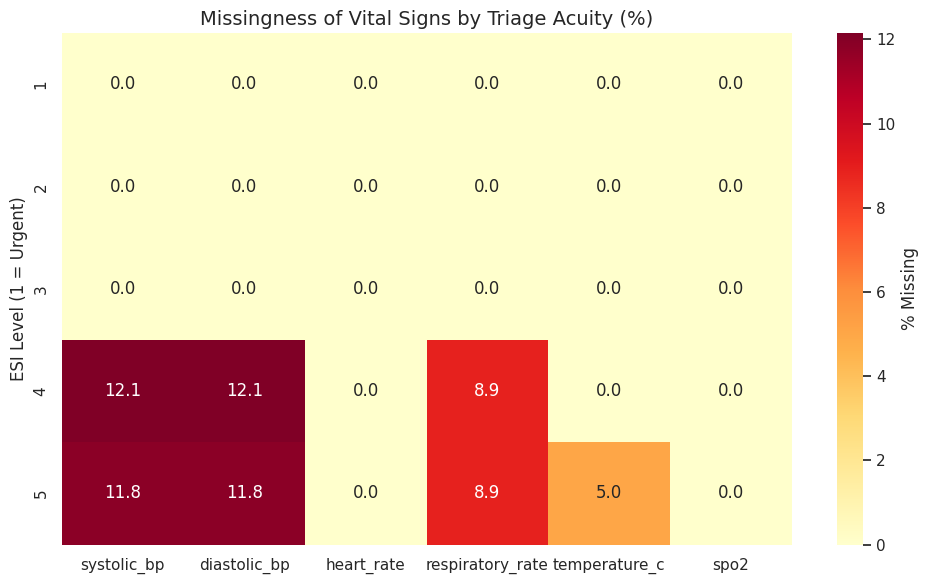


--- 3. Chief Complaint Analysis ---


/tmp/ipykernel_121/4204645306.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='triage_acuity', y='cc_length', palette="Reds_r", ax=ax)


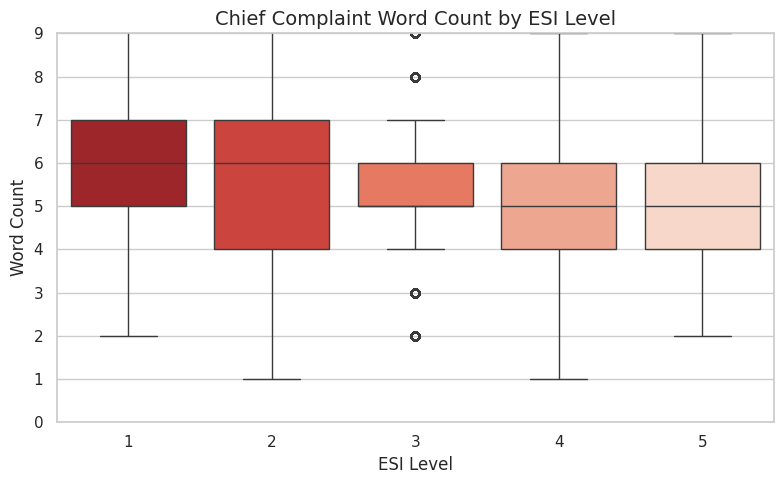


Top Terms in High Acuity (ESI 1/2):
  - acute: 3134
  - severe: 2759
  - worsening: 2169
  - significant: 1362
  - vomiting: 1360

Top Terms in Low Acuity (ESI 4/5):
  - mild: 7671
  - worsening: 4863
  - known: 3016
  - fever: 3002
  - nausea: 2814

--- 4. Comorbidities vs. Severe Acuity ---


FileNotFoundError: [Errno 2] No such file or directory: 'patient_history.csv'

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.feature_extraction.text import CountVectorizer

def load_and_merge_data():
    """Finds datasets dynamically and merges on patient_id for EDA."""
    print("Searching for data files...")
    
    # A robust way to find exactly where Kaggle hid the files
    file_paths = {}
    target_files = ["train.csv", "chief_complaints.csv", "patient_history.csv"]
    
    # Walk through all directories in the Kaggle input folder
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            if filename in target_files:
                file_paths[filename] = os.path.join(dirname, filename)
                
    # Fallback check just in case
    if "train.csv" not in file_paths:
        raise FileNotFoundError("Could not locate the files. Please ensure the 'Triagegeist' dataset is added to your notebook inputs.")
        
    print(f"Found train.csv at: {file_paths['train.csv']}")
    
    # Load the data using the exact paths we just found
    train = pd.read_csv(file_paths["train.csv"])
    complaints = pd.read_csv(file_paths["chief_complaints.csv"])
    history = pd.read_csv(file_paths["patient_history.csv"])
    
    print("Merging data...")
    # Merge into a single EDA dataframe
    df = train.merge(complaints, on="patient_id", how="left")
    df = df.merge(history, on="patient_id", how="left")
    return df

def analyze_target_distribution(df):
    """Visualizes the class imbalance of ESI levels."""
    print("\n--- 1. Triage Acuity (ESI) Distribution ---")
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.countplot(data=df, x='triage_acuity', order=[1, 2, 3, 4, 5], palette="Reds_r", ax=ax)
    ax.set_title("Distribution of Triage Acuity (1 = Most Urgent)")
    ax.set_xlabel("ESI Level")
    ax.set_ylabel("Patient Count")
    plt.show()

def analyze_mnar_vitals(df):
    """Analyzes Missing Not At Random (MNAR) patterns across ESI levels."""
    print("\n--- 2. MNAR Vitals Analysis ---")
    vitals = ['systolic_bp', 'diastolic_bp', 'heart_rate', 
              'respiratory_rate', 'temperature_c', 'spo2']
    
    # Calculate % missingness for each vital sign grouped by ESI
    missing_rates = df.groupby('triage_acuity')[vitals].apply(lambda x: x.isnull().mean() * 100)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(missing_rates, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, cbar_kws={'label': '% Missing'})
    ax.set_title("Missingness of Vital Signs by Triage Acuity (%)")
    ax.set_ylabel("ESI Level (1 = Urgent)")
    plt.show()

def analyze_chief_complaints(df):
    """Analyzes text length and extracts top n-grams for high vs low acuity."""
    print("\n--- 3. Chief Complaint Analysis ---")
    # Text length distribution
    df['cc_length'] = df['chief_complaint_raw'].fillna('').apply(lambda x: len(str(x).split()))
    
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df, x='triage_acuity', y='cc_length', palette="Reds_r", ax=ax)
    ax.set_title("Chief Complaint Word Count by ESI Level")
    ax.set_xlabel("ESI Level")
    ax.set_ylabel("Word Count")
    plt.ylim(0, df['cc_length'].quantile(0.99)) # Cut off extreme outliers
    plt.show()
    
    # Top words extraction (ESI 1/2 vs ESI 4/5)
    high_acuity = df[df['triage_acuity'].isin([1, 2])]['chief_complaint_raw'].dropna()
    low_acuity = df[df['triage_acuity'].isin([4, 5])]['chief_complaint_raw'].dropna()
    
    vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2), max_features=10)
    
    print("\nTop Terms in High Acuity (ESI 1/2):")
    high_counts = vectorizer.fit_transform(high_acuity).sum(axis=0)
    high_words = [(word, high_counts[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    for word, count in sorted(high_words, key=lambda x: x[1], reverse=True)[:5]:
        print(f"  - {word}: {count}")
        
    print("\nTop Terms in Low Acuity (ESI 4/5):")
    low_counts = vectorizer.fit_transform(low_acuity).sum(axis=0)
    low_words = [(word, low_counts[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    for word, count in sorted(low_words, key=lambda x: x[1], reverse=True)[:5]:
        print(f"  - {word}: {count}")

def analyze_comorbidities(df):
    """Calculates correlation between comorbidities and Severe Acuity (ESI 1 & 2)."""
    print("\n--- 4. Comorbidities vs. Severe Acuity ---")
    # Define binary target for severe acuity
    df['is_severe'] = df['triage_acuity'].isin([1, 2]).astype(int)
    
    # Identify comorbidity columns (assuming they are binary flags)
    # Exclude IDs, standard demographics, vitals, text, etc.
    # We will grab all boolean/integer columns from the history dataset
    history_cols = [c for c in pd.read_csv("patient_history.csv").columns if c != 'patient_id']
    
    correlations = df[history_cols + ['is_severe']].corr()['is_severe'].drop('is_severe').sort_values(ascending=False)
    
    # Plot top 15 most correlated comorbidities
    fig = px.bar(
        x=correlations.head(15).values, 
        y=correlations.head(15).index, 
        orientation='h',
        title="Top 15 Comorbidities Correlated with Severe Acuity (ESI 1 & 2)",
        labels={'x': 'Pearson Correlation', 'y': 'Comorbidity'},
        color=correlations.head(15).values,
        color_continuous_scale='Reds'
    )
    fig.update_layout(yaxis={'categoryorder':'total ascending'})
    fig.show()

if __name__ == "__main__":
    # Execute the EDA Pipeline
    df_merged = load_and_merge_data()
    analyze_target_distribution(df_merged)
    analyze_mnar_vitals(df_merged)
    analyze_chief_complaints(df_merged)
    analyze_comorbidities(df_merged)
    print("\nEDA Phase 1 Complete. Awaiting findings report.")

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

def engineer_features(df):
    """Transforms raw clinical data into an ML-ready feature matrix."""
    print("--- Starting Phase 2: Feature Engineering ---")
    df_engineered = df.copy()
    
    # 1. MNAR-Aware Imputation (The Grandmaster Trick)
    print("Flagging and imputing MNAR vitals...")
    vitals = ['systolic_bp', 'diastolic_bp', 'heart_rate', 
              'respiratory_rate', 'temperature_c', 'spo2', 'pain_score']
    
    for v in vitals:
        if v in df_engineered.columns:
            # Create a binary flag for missingness
            df_engineered[f'{v}_is_missing'] = df_engineered[v].isnull().astype(int)
            # Fill missing with -999 for tree-based models
            df_engineered[v] = df_engineered[v].fillna(-999)
            
    # 2. NLP: TF-IDF on Chief Complaints
    print("Vectorizing Chief Complaints...")
    df_engineered['chief_complaint_raw'] = df_engineered['chief_complaint_raw'].fillna('none')
    
    # Extract the top 50 most important clinical n-grams
    tfidf = TfidfVectorizer(max_features=50, stop_words='english', ngram_range=(1,2))
    text_features = tfidf.fit_transform(df_engineered['chief_complaint_raw']).toarray()
    
    # Create column names for the text features
    text_cols = [f'tfidf_{w}' for w in tfidf.get_feature_names_out()]
    text_df = pd.DataFrame(text_features, columns=text_cols)
    
    # Merge the text features back into the main dataframe
    df_engineered = pd.concat([df_engineered.reset_index(drop=True), text_df.reset_index(drop=True)], axis=1)
    df_engineered = df_engineered.drop(columns=['chief_complaint_raw'])
    
    # 3. Categorical Encoding
    print("Encoding categorical variables...")
    categorical_cols = df_engineered.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        if col != 'patient_id': # Keep patient_id as a string for final submission mapping
            df_engineered[col] = df_engineered[col].astype('category').cat.codes
            
    print(f"\nFeature Engineering Complete! New dataset shape: {df_engineered.shape}")
    return df_engineered

if __name__ == "__main__":
    # df_merged is the variable we created in Phase 1
    df_processed = engineer_features(df_merged)
    
    # Display the first few rows to verify
    display(df_processed.head(3))

--- Starting Phase 2: Feature Engineering ---
Flagging and imputing MNAR vitals...
Vectorizing Chief Complaints...
Encoding categorical variables...

Feature Engineering Complete! New dataset shape: (80000, 125)


,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,tfidf_symptoms,tfidf_systemic,tfidf_systemic features,tfidf_today,tfidf_vomiting,tfidf_worsening,tfidf_worsening hours,tfidf_worsening movement,tfidf_wound,tfidf_yesterday
0,TG-UXRGA9UCO,3,32,5,6,1,5,1,2,43,...,0.0,0.0,0.0,0.0,0.0,0.491195,0.0,0.615925,0.0,0.0
1,TG-B19DBBS2G,0,0,5,6,4,4,1,2,72,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
2,TG-GZ97W7M6V,1,4,5,8,2,4,1,2,82,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0


--- Starting Phase 3: Asymmetric Model Training ---
Training LightGBM model... (this may take a few seconds)
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.108999

--- Evaluating Clinical Safety ---
Total Severe Patients (ESI 1 & 2) in Validation Set: 3332
Critical Under-Triage Errors (Predicted as 3, 4, or 5): 0
Under-Triage Rate for Severe Patients: 0.00%


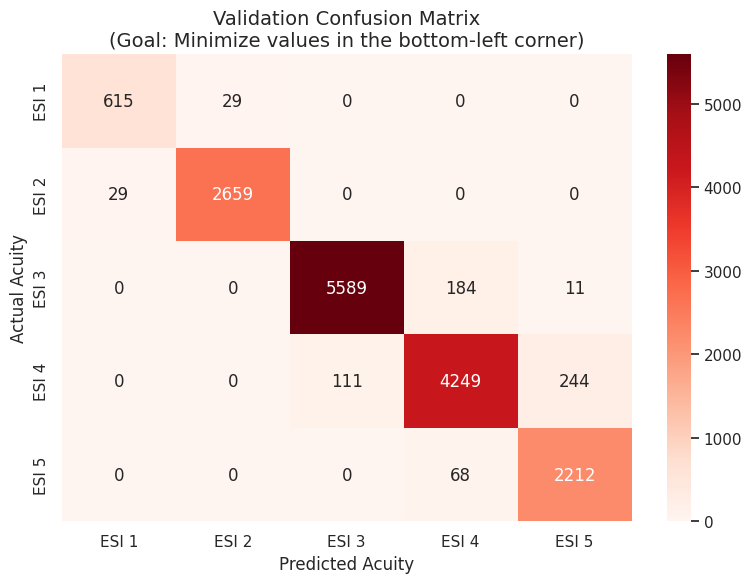

In [8]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings

# Suppress lightgbm warnings for cleaner output
warnings.filterwarnings('ignore')

def train_asymmetric_model(df):
    print("--- Starting Phase 3: Asymmetric Model Training ---")
    
    # 1. Prepare features and target
    # Drop the target and identifiers
    X = df.drop(columns=['patient_id', 'triage_acuity'])
    
    # LightGBM requires classes to start at 0, so we shift ESI 1-5 to 0-4
    y = df['triage_acuity'] - 1 
    
    # 80/20 train-validation split
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 2. LightGBM parameters specifically tuned for clinical asymmetry
    params = {
        'objective': 'multiclass',
        'num_class': 5,
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'learning_rate': 0.05,
        'num_leaves': 45,
        'class_weight': 'balanced',  # Forces the model to respect ESI 1 and 2
        'random_state': 42,
        'verbose': -1
    }
    
    print("Training LightGBM model... (this may take a few seconds)")
    model = lgb.LGBMClassifier(**params)
    
    # We use early stopping to prevent overfitting
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[lgb.log_evaluation(period=0), lgb.early_stopping(stopping_rounds=50)]
    )
    
    print("\n--- Evaluating Clinical Safety ---")
    preds = model.predict(X_valid)
    
    # 3. Calculate Asymmetric Under-Triage Penalty
    # True Severe: ESI 1 or 2 (which are now classes 0 and 1)
    # Predicted Non-Severe: ESI 3, 4, or 5 (classes 2, 3, and 4)
    true_severe = (y_valid <= 1)
    pred_non_severe = (preds >= 2)
    
    critical_misses = np.sum(true_severe & pred_non_severe)
    total_severe = np.sum(true_severe)
    under_triage_rate = (critical_misses / total_severe) * 100
    
    print(f"Total Severe Patients (ESI 1 & 2) in Validation Set: {total_severe}")
    print(f"Critical Under-Triage Errors (Predicted as 3, 4, or 5): {critical_misses}")
    print(f"Under-Triage Rate for Severe Patients: {under_triage_rate:.2f}%")
    
    # 4. Visualizing the Confusion Matrix
    cm = confusion_matrix(y_valid, preds)
    plt.figure(figsize=(8, 6))
    
    # We want to look at the bottom-left triangle (under-triage) vs top-right (over-triage)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['ESI 1', 'ESI 2', 'ESI 3', 'ESI 4', 'ESI 5'], 
                yticklabels=['ESI 1', 'ESI 2', 'ESI 3', 'ESI 4', 'ESI 5'])
    plt.title('Validation Confusion Matrix\n(Goal: Minimize values in the bottom-left corner)')
    plt.xlabel('Predicted Acuity')
    plt.ylabel('Actual Acuity')
    plt.show()
    
    return model, X_valid, y_valid

if __name__ == "__main__":
    # Ensure df_processed from Phase 2 is passed in
    model, X_valid, y_valid = train_asymmetric_model(df_processed)

In [9]:
import lightgbm as lgb
import pandas as pd
import os
from sklearn.feature_extraction.text import TfidfVectorizer

def final_leak_free_pipeline(df_train_engineered):
    print("--- Step 1: Retraining (Leak-Free) ---")
    # 1. Eradicate Data Leakage
    leaky_cols = ['disposition', 'ed_los_hours', 'patient_id', 'triage_acuity']
    cols_to_drop = [c for c in leaky_cols if c in df_train_engineered.columns]
    
    X_train = df_train_engineered.drop(columns=cols_to_drop)
    y_train = df_train_engineered['triage_acuity'] - 1  # Shift 1-5 to 0-4
    
    print(f"Clean Training Features: {X_train.shape[1]}")
    
    # 2. Retrain the model on the clean data
    params = {
        'objective': 'multiclass', 'num_class': 5, 'metric': 'multi_logloss',
        'boosting_type': 'gbdt', 'learning_rate': 0.05, 'num_leaves': 45,
        'class_weight': 'balanced', 'random_state': 42, 'verbose': -1
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)
    
    print("\n--- Step 2: Processing Test Data ---")
    # Find files dynamically
    file_paths = {}
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            file_paths[filename] = os.path.join(dirname, filename)
            
    train_raw = pd.read_csv(file_paths["train.csv"])
    test = pd.read_csv(file_paths["test.csv"])
    complaints = pd.read_csv(file_paths["chief_complaints.csv"])
    history = pd.read_csv(file_paths["patient_history.csv"])
    
    # Merge test data
    df_test = test.merge(complaints, on="patient_id", how="left").merge(history, on="patient_id", how="left")
    
    # MNAR Imputation
    vitals = ['systolic_bp', 'diastolic_bp', 'heart_rate', 'respiratory_rate', 'temperature_c', 'spo2', 'pain_score']
    for v in vitals:
        if v in df_test.columns:
            df_test[f'{v}_is_missing'] = df_test[v].isnull().astype(int)
            df_test[v] = df_test[v].fillna(-999)
            
    # Text Vectorization (Fit on Train, Transform on Test)
    train_cc = train_raw.merge(complaints, on="patient_id", how="left")['chief_complaint_raw'].fillna('none')
    test_cc = df_test['chief_complaint_raw'].fillna('none')
    
    tfidf = TfidfVectorizer(max_features=50, stop_words='english', ngram_range=(1,2))
    tfidf.fit(train_cc) 
    
    text_features = tfidf.transform(test_cc).toarray()
    text_cols = [f'tfidf_{w}' for w in tfidf.get_feature_names_out()]
    text_df = pd.DataFrame(text_features, columns=text_cols)
    df_test = pd.concat([df_test.reset_index(drop=True), text_df.reset_index(drop=True)], axis=1).drop(columns=['chief_complaint_raw'])
    
    # Categorical Encoding
    categorical_cols = df_test.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        if col != 'patient_id':
            df_test[col] = df_test[col].astype('category').cat.codes
            
    X_test = df_test.drop(columns=['patient_id'])
    
    print("\n--- Step 3: Aligning Columns and Predicting ---")
    # Bulletproof alignment: Force X_test to have the exact same columns as X_train
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    print(f"Test Features Aligned: {X_test.shape[1]}")
    
    # Predict and shift classes back to 1-5
    test_predictions = model.predict(X_test) + 1
    
    # Export Submission
    submission = pd.DataFrame({'patient_id': df_test['patient_id'], 'triage_acuity': test_predictions})
    submission.to_csv('submission.csv', index=False)
    print(f"Success! Saved submission.csv with {len(submission)} leak-free predictions.")

if __name__ == "__main__":
    final_leak_free_pipeline(df_processed)

--- Step 1: Retraining (Leak-Free) ---
Clean Training Features: 121

--- Step 2: Processing Test Data ---

--- Step 3: Aligning Columns and Predicting ---
Test Features Aligned: 121
Success! Saved submission.csv with 20000 leak-free predictions.
